In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/heart (1).csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [26]:
df.shape

(1025, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


<Axes: xlabel='target'>

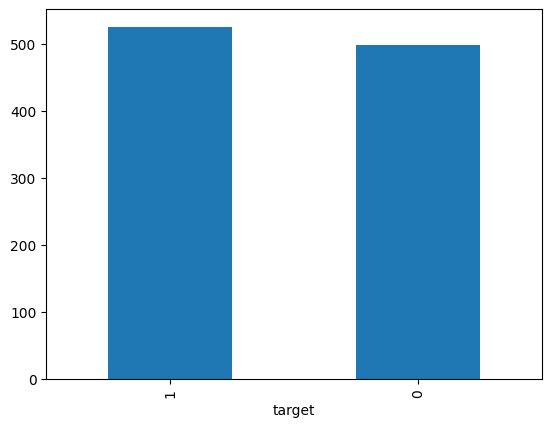

In [6]:
df['target'].value_counts().plot(kind  = "bar")

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
624,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1
414,59,1,3,170,288,0,0,159,0,0.2,1,0,3,0
454,65,0,0,150,225,0,0,114,0,1.0,1,3,3,0
488,54,0,1,132,288,1,0,159,1,0.0,2,1,2,1
360,48,1,0,122,222,0,0,186,0,0.0,2,0,2,1


In [9]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)   # should have more columns now
print(df_encoded.head())

(1025, 20)
   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target   cp_1  \
0   52    1       125   212    0      168      0      1.0   2       0  False   
1   53    1       140   203    1      155      1      3.1   0       0  False   
2   70    1       145   174    0      125      1      2.6   0       0  False   
3   61    1       148   203    0      161      0      0.0   1       0  False   
4   62    0       138   294    1      106      0      1.9   3       0  False   

    cp_2   cp_3  restecg_1  restecg_2  slope_1  slope_2  thal_1  thal_2  \
0  False  False       True      False    False     True   False   False   
1  False  False      False      False    False    False   False   False   
2  False  False       True      False    False    False   False   False   
3  False  False       True      False    False     True   False   False   
4  False  False       True      False     True    False   False    True   

   thal_3  
0    True  
1    True  
2    True  
3    True

In [10]:
df_encoded = df_encoded.astype(int)

In [12]:
df_encoded

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1,2,0,0,0,0,1,0,0,1,0,0,1
1,53,1,140,203,1,155,1,3,0,0,0,0,0,0,0,0,0,0,0,1
2,70,1,145,174,0,125,1,2,0,0,0,0,0,1,0,0,0,0,0,1
3,61,1,148,203,0,161,0,0,1,0,0,0,0,1,0,0,1,0,0,1
4,62,0,138,294,1,106,0,1,3,0,0,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,140,221,0,164,1,0,0,1,1,0,0,1,0,0,1,0,1,0
1021,60,1,125,258,0,141,1,2,1,0,0,0,0,0,0,1,0,0,0,1
1022,47,1,110,275,0,118,1,1,1,0,0,0,0,0,0,1,0,0,1,0
1023,50,0,110,254,0,159,0,0,0,1,0,0,0,0,0,0,1,0,1,0


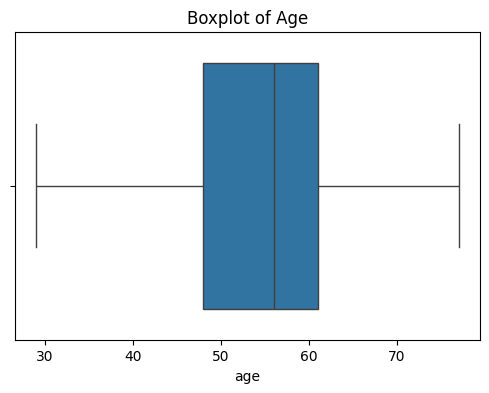

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('target', axis=1)   # features (everything except target)
y = df_encoded['target']                 # what we're predicting

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(820, 19) (205, 19)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test

In [17]:
X_train_scaled

array([[ 0.81162633, -1.50996689,  0.31472862, ..., -0.24378582,
         0.93617851, -0.82690884],
       [ 0.15224695, -1.50996689,  3.76764257, ..., -0.24378582,
        -1.06817235,  1.20932314],
       [ 0.26214351,  0.66226618, -0.24219298, ..., -0.24378582,
        -1.06817235,  1.20932314],
       ...,
       [ 0.81162633, -1.50996689,  1.53995615, ..., -0.24378582,
        -1.06817235,  1.20932314],
       [-0.17744274,  0.66226618, -0.52065378, ..., -0.24378582,
        -1.06817235,  1.20932314],
       [ 0.70172977,  0.66226618,  0.98303455, ..., -0.24378582,
         0.93617851, -0.82690884]])

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8536585365853658

Confusion Matrix:
 [[78 22]
 [ 8 97]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.78      0.84       100
           1       0.82      0.92      0.87       105

    accuracy                           0.85       205
   macro avg       0.86      0.85      0.85       205
weighted avg       0.86      0.85      0.85       205



In [20]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

CV Scores: [0.85365854 0.87195122 0.84146341 0.82926829 0.83536585]
Mean CV Accuracy: 0.8463414634146341
Std Dev: 0.01513374834876935


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0

Confusion Matrix:
 [[100   0]
 [  0 105]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [22]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Total rows: 1025
Duplicate rows: 723


In [27]:
df_clean = df.drop_duplicates()

print("Unique rows:", df_clean.shape)

# Re-encode
categorical_cols = ['cp', 'restecg', 'slope', 'thal']

df_clean_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

Unique rows: (302, 14)


In [28]:
X = df_clean_encoded.drop('target', axis=1)
y = df_clean_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Re-scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(241, 19) (61, 19)


In [30]:
# Retrain logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())


=== Logistic Regression ===
Accuracy: 0.819672131147541
Confusion Matrix:
 [[22  6]
 [ 5 28]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80        28
           1       0.82      0.85      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

Mean CV Accuracy: 0.7966836734693877
Std Dev: 0.015455151281790869


In [31]:
import joblib

joblib.dump(model, 'logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']